<a href="https://colab.research.google.com/github/kkbin505/MEng_classify_fashion_MNIST/blob/baseline-model---Angela/Baseline_Model_Analysis_Angela.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!git clone https://github.com/kkbin505/MEng_classify_fashion_MNIST.git

Cloning into 'MEng_classify_fashion_MNIST'...
remote: Enumerating objects: 2949, done.
remote: Counting objects: 100% (171/171), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 2949 (delta 15), reused 139 (delta 2), pack-reused 2778 (from 2)
Receiving objects: 100% (2949/2949), 136.77 MiB | 20.94 MiB/s, done.
Resolving deltas: 100% (480/480), done.


In [8]:
import os
os.chdir("/content/MEng_classify_fashion_MNIST")
!pwd

/content/MEng_classify_fashion_MNIST


In [9]:
!pip install tensorflow matplotlib numpy

In [10]:
import os
import requests
import gzip
import shutil

# Create data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# URLs for Fashion MNIST files
files = {
    "train-images-idx3-ubyte.gz": "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz": "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz": "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz": "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-labels-idx1-ubyte.gz"
}

# Download and unzip each file
for filename, url in files.items():
    gz_path = os.path.join("data", filename)
    out_path = os.path.join("data", filename.replace(".gz", ""))

    # Download the file
    if not os.path.exists(out_path):
        print(f"Downloading {filename}...")
        r = requests.get(url, stream=True)
        with open(gz_path, "wb") as f:
            f.write(r.content)

        # Unzip the file
        with gzip.open(gz_path, 'rb') as f_in:
            with open(out_path, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)

        # Remove the .gz file
        os.remove(gz_path)
        print(f"{filename} downloaded and extracted.")
    else:
        print(f"{filename} already exists.")


train-images-idx3-ubyte.gz already exists.
train-labels-idx1-ubyte.gz already exists.
t10k-images-idx3-ubyte.gz already exists.
t10k-labels-idx1-ubyte.gz already exists.


In [11]:
!ls

classify_fashion_notebook.ipynb  data  README.md
classify_fasion_MNIST.py	 img   step_by_step_guide.md


Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7819 - loss: 0.6365 - val_accuracy: 0.8575 - val_loss: 0.3991
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8612 - loss: 0.3865 - val_accuracy: 0.8628 - val_loss: 0.4021
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8740 - loss: 0.3460 - val_accuracy: 0.8685 - val_loss: 0.3575
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8867 - loss: 0.3079 - val_accuracy: 0.8752 - val_loss: 0.3365
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8916 - loss: 0.2933 - val_accuracy: 0.8775 - val_loss: 0.3297
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8971 - loss: 0.2779 - val_accuracy: 0.8720 - val_loss: 0.3384
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9012 - loss: 0.2672 - val_accuracy: 0.8850 - val_loss: 0.3147
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accur

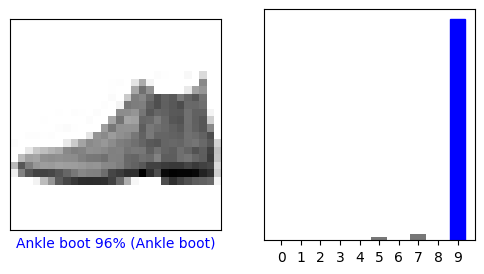


Plotting training history...


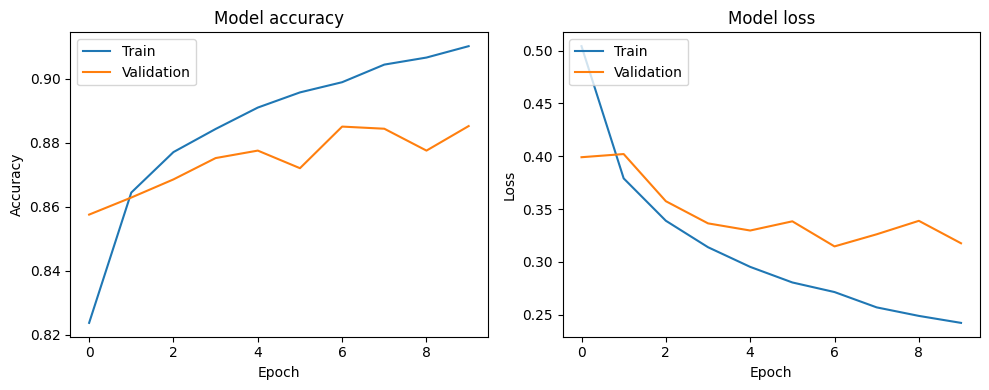

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# Define data location
DATA_PATH = 'data' # <-- EDIT THIS PATH

# Step 1: Load the Fashion MNIST Dataset from local
def load_fashion_mnist_data(path, kind='train'):
    """Load Fashion MNIST data from idx3-ubyte files."""
    if kind == 'train':
        labels_filename = 'train-labels-idx1-ubyte'
        images_filename = 'train-images-idx3-ubyte'
    else:
        labels_filename = 't10k-labels-idx1-ubyte'
        images_filename = 't10k-images-idx3-ubyte'

    labels_path = os.path.join(path, labels_filename)
    images_path = os.path.join(path, images_filename)

    with open(labels_path, 'rb') as lbpath:
        lbpath.seek(8)
        labels = np.fromfile(lbpath, dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        imgpath.seek(16)
        images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 28, 28)

    return images, labels



try:
    # Load training data
    train_images, train_labels = load_fashion_mnist_data(DATA_PATH, kind='train')
    # Load test data
    test_images, test_labels = load_fashion_mnist_data(DATA_PATH, kind='t10k')
except FileNotFoundError as e:
    print(f"Error loading file: {e.filename}")
    print(f"Please make sure the data files are located in the '{DATA_PATH}' directory.")
    exit()


# Define class names for the labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Step 2: Preprocess the Data, normilize pixel data from 0~200 to 0~1.0
train_images = train_images / 255.0
test_images = test_images / 255.0

# Step 3: Build the Neural Network Model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 4: Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display a summary of the model's architecture
print("Model Summary:")
model.summary()

# Step 5: Train the Model
print("\nStarting model training...")
history = model.fit(train_images, train_labels, epochs=10, validation_split=0.1)
print("Model training finished.")

# Step 6: Evaluate the Model's Accuracy
print("\nEvaluating model on test data...")
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

# Step 7: Make Predictions
predictions = model.predict(test_images)

# Helper functions to visualize the predictions
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% ({class_names[true_label]})",
               color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

# Let's visualize the prediction for the first image
print("\nVisualizing a prediction...")
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], test_labels)
plt.show()

# Plot training & validation accuracy values
print("\nPlotting training history...")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()
